# Telco Customer Churn Prediction Project | michaeltsop.com

### Loading the Dataset

In [55]:
# Loading the dataset from Kaggle using kagglehub
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file
file_path = "WA_Fn-UseC_-Telco-Customer-Churn.csv"

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "blastchar/telco-customer-churn",
  file_path,
  # Provide any additional arguments like 
  # sql_query or pandas_kwargs. See the 
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

C:\Users\mihal\AppData\Local\Temp\ipykernel_2544\4035313017.py:11: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


In [56]:
# Loading libraries for data analysis
import pandas as pd

### Exploring the dataset

In [57]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [58]:
# Get a summary of the DataFrame
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [59]:
# Total charges should be numeric, but it is being read as an object. Let's convert it to a numeric type and handle any errors that arise from non-numeric values.
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [60]:
# show null values
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [61]:
# Dropping null values from the dataset
df.dropna(inplace=True)

In [62]:
# Get summary statistics for numeric columns
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7032.000000,7032.000000,7032.000000,7032.000000
mean,0.162400,32.421786,64.798208,2283.300441
std,0.368844,24.545260,30.085974,2266.771362
min,0.000000,1.000000,18.250000,18.800000
25%,0.000000,9.000000,35.587500,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.862500,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


In [63]:
# Lets see how many Yes and No values we have in the target column 'Churn'
print(df['Churn'].value_counts())

# Display in percentage
print(df['Churn'].value_counts(normalize=True) * 100)

Churn
No     5163
Yes    1869
Name: count, dtype: int64
Churn
No     73.421502
Yes    26.578498
Name: proportion, dtype: float64


~73% NO = Imbalanced Data!

### Visuals

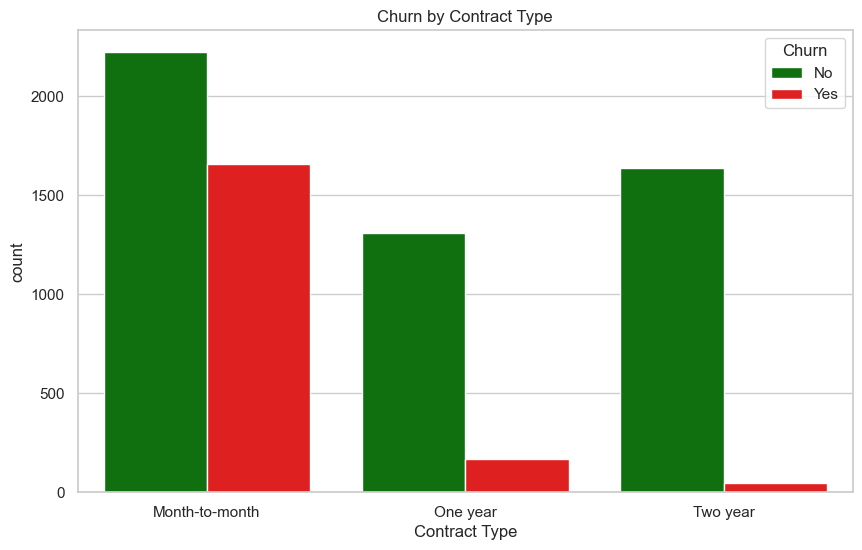

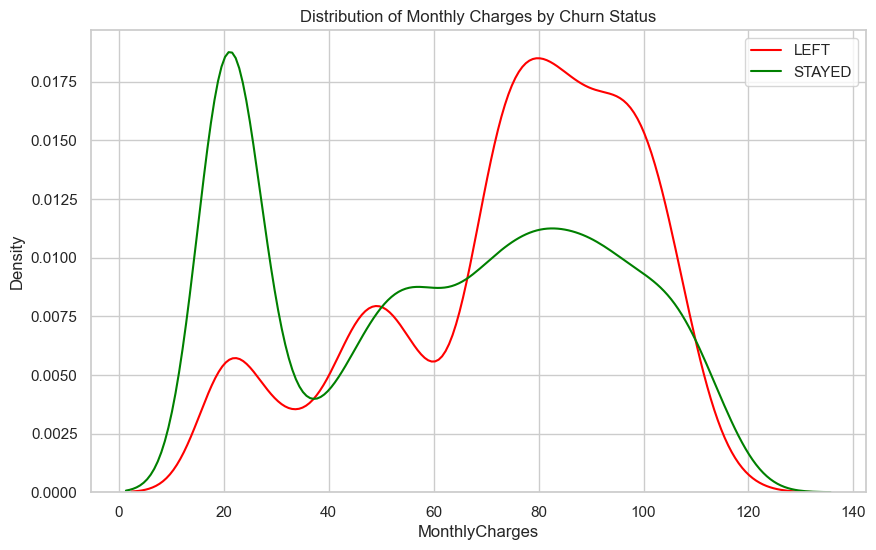

In [64]:
import matplotlib.pyplot as plt
import seaborn as sns

# Setting up the theme
sns.set_theme(style="whitegrid")

# Graph 1: Churn X Contract Type
plt.figure(figsize=(10, 6))
# color red for churn no and green for churn yes
sns.set_palette(sns.color_palette(["green", "red"]))
sns.countplot(data=df, x='Contract', hue='Churn')
plt.title('Churn by Contract Type')
plt.xlabel('Contract Type')
plt.show()

# Graph 2: Churn X Monthly Charges
plt.figure(figsize=(10, 6))
sns.kdeplot(df[df['Churn'] == 'Yes']['MonthlyCharges'], label='LEFT', color='red')
sns.kdeplot(df[df['Churn'] == 'No']['MonthlyCharges'], label='STAYED', color='green')
plt.title('Distribution of Monthly Charges by Churn Status')
plt.legend()
plt.show()

### Encoding Data

In [ ]:
# Transforming churn to 1 and 0 for yes - no respectrively
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# Dropping customerID as it is not useful for prediction
df.drop('customerID', axis=1, inplace=True)

# One hot encoding for categorical variables - dtype int for 0 1 instead of boolean
df_encoded = pd.get_dummies(df, drop_first=True, dtype=int)

In [66]:
df_encoded.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,0,1,0,0,1,...,0,0,0,0,0,0,1,0,1,0
1,0,34,56.95,1889.50,0,1,0,0,1,0,...,0,0,0,0,1,0,0,0,0,1
2,0,2,53.85,108.15,1,1,0,0,1,0,...,0,0,0,0,0,0,1,0,0,1
3,0,45,42.30,1840.75,0,1,0,0,0,1,...,0,0,0,0,1,0,0,0,0,0
4,0,2,70.70,151.65,1,0,0,0,1,0,...,0,0,0,0,0,0,1,0,1,0


### Machine Learning - Testing various models

In [70]:
# Splitting data to features (X) and target variable (y)
X = df_encoded.drop('Churn', axis=1) # FEATURES
y = df_encoded['Churn'] # TARGET VARIABLE

# Splitting data to training (80%) and testing (20%) sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Random Forest Classifiier

In [74]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report 

# Create a Random Forest Classifier
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model on the training data
rf_classifier.fit(X_train, y_train)

# Make predictions on the test set to check the performance of the model
y_pred = rf_classifier.predict(X_test)

# Evaluate the model using Confusion Matrix and Classification Report
print(" Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print(" Classification Report:")
print(classification_report(y_test, y_pred))    

 Confusion Matrix:
[[927 106]
 [196 178]]
 Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1033
           1       0.63      0.48      0.54       374

    accuracy                           0.79      1407
   macro avg       0.73      0.69      0.70      1407
weighted avg       0.77      0.79      0.78      1407



- 79% Accuracy
- Recall 48% = Finds half of the customers who churned
- Needs Improvement

In [78]:
# Ill use SMOTE to handle the imbalance of the dataset. 
# SMOTE is generating synthetic samples of Churn = 1 (minority) to prevent the model from being biased towards the majority class (Churn = 0).

from imblearn.over_sampling import SMOTE
sm = SMOTE(random_state=42)

# only using SMOTE on the training data
X_train_smote, y_train_smote = sm.fit_resample(X_train, y_train)

print("Before SMOTE, counts of label '1': {}".format(sum(y_train == 1)))
print("After SMOTE, counts of label '1': {}".format(sum(y_train_smote == 1)))


Before SMOTE, counts of label '1': 1495
After SMOTE, counts of label '1': 4130


In [79]:
# Random Forest Classifier on the SMOTE data & hyperparameter tuning
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV # faster than GridSearchCV for hyperparameter tuning

# hyperaparameters to test to see which combination gives the best performance
param_dist = {  
    'n_estimators': [100, 200, 300], # number of trees in the forest
    'max_depth': [None, 10, 20, 30], # maximum depth of the tree
    'min_samples_split': [2, 5, 10], # minimum number of samples required to split an internal node
    'min_samples_leaf': [1, 2, 4], # minimum number of samples required to be at a leaf node
    'criterion': ['gini', 'entropy'] # function to measure the quality of a split
}

rf_classifier2 = RandomizedSearchCV(
        estimator=RandomForestClassifier(random_state=42),
        param_distributions=param_dist,
        n_iter=10, # number of parameter settings that are sampled
        cv=5, # number of folds for cross-validation
        random_state=42,
        n_jobs=-1 # use all available cpu cores for faster results
)

# Train the model on the SMOTE data
rf_classifier2.fit(X_train_smote, y_train_smote)

# Best hyperparameters found by RandomizedSearchCV
print("Best Hyperparameters:", rf_classifier2.best_params_)

# Make predictions on the test set using the best estimator
y_pred_smote = rf_classifier2.best_estimator_.predict(X_test)

# Evaluate the model using Confusion Matrix and Classification Report
print(" Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_smote))
print(" Classification Report:")
print(classification_report(y_test, y_pred_smote))

Best Hyperparameters: {'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_depth': None, 'criterion': 'entropy'}
 Confusion Matrix:
[[848 185]
 [153 221]]
 Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.82      0.83      1033
           1       0.54      0.59      0.57       374

    accuracy                           0.76      1407
   macro avg       0.70      0.71      0.70      1407
weighted avg       0.77      0.76      0.76      1407



- Recall for 1 went from 0.48 to 0.59 ~ 60% Chance to caught the customer who is willing to leave
- Accuracy droped from 79% to 76%.

- Increasing the recall for 1 is of higher value for this stage as its possibly less harmful to make an offer for a customer that is going to stay than losing one (bebause of less recall)

### XGBoost Model

In [ ]:
# Ill train on SMOTE data again as the imbalance remains.

# Parameters to test for xgb
xgb_params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
    'scale_pos_weight': [1] # since the dataset is now balanced after SMOTE, we can set scale_pos_weight to 1 
    }

# Creating RandomizedSearchCV for XGBoost
from xgboost import XGBClassifier

xgb_classifier = RandomizedSearchCV(
    estimator=XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss'),
    param_distributions=xgb_params,
    n_iter=10,
    cv=5,
    random_state=42,
    n_jobs=-1 # use all available cpu cores for faster results
)   

# Train the XGBoost model on the SMOTE data
xgb_classifier.fit(X_train_smote, y_train_smote)

# Make predictions on the test set using the best estimator for XGBoost
y_pred_xgb = xgb_classifier.best_estimator_.predict(X_test)

# Evaluate the XGBoost model using Confusion Matrix and Classification Report
print(" Confusion Matrix for XGBoost:")
print(confusion_matrix(y_test, y_pred_xgb))

print(" Classification Report for XGBoost:")
print(classification_report(y_test, y_pred_xgb))


c:\Users\mihal\miniconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [15:13:35] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best Hyperparameters for XGBoost: {'subsample': 0.8, 'scale_pos_weight': 1, 'n_estimators': 100, 'max_depth': 7, 'learning_rate': 0.1, 'colsample_bytree': 0.8}
 Confusion Matrix for XGBoost:
[[839 194]
 [152 222]]
 Classification Report for XGBoost:
              precision    recall  f1-score   support

           0       0.85      0.81      0.83      1033
           1       0.53      0.59      0.56       374

    accuracy                           0.75      1407
   macro avg       0.69      0.70      0.70      1407
weighted avg       0.76      0.75      0.76      1407



- Very small changes with the tuned RF Classifier

### Feature Importance Visual - From RF CLF

C:\Users\mihal\AppData\Local\Temp\ipykernel_2544\1864627422.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='Purples_d')


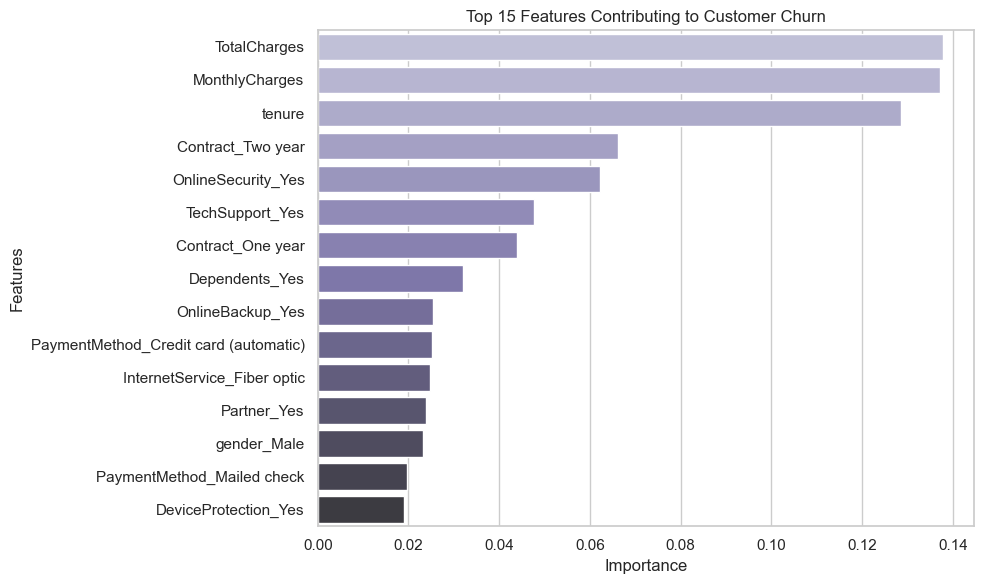

In [90]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Feature importance from the best Random Forest model
importances = rf_classifier2.best_estimator_.feature_importances_
feature_names = X.columns

# Create a DataFrame for feature importance
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})

# Sorting the top 15 features that encourage churn
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False).head(15)

# Visualizing
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='Purples_d')

plt.title('Top 15 Features Contributing to Customer Churn')
plt.xlabel('Importance')
plt.ylabel('Features')
plt.tight_layout()
plt.show()


- Total Charges: the more a customer has spent overall, the more they weigh their options. High lifetime spenders are our most "at-risk" group.

- Monthly Charges: High monthly bills are a massive red flag. When that monthly invoice hits a certain threshold (usually $70-$100), customers start looking for the exit door.

- Tenure: The data shows a huge spike in churn during the first few months. If we don’t "hook" a customer in the beginning, we lose them. The longer they stay the more chances they have staying more.

- Contract Type: "Month-to-month" contracts are high risk for losing a customer. Without a long-term commitment, it’s too easy for customers to leave for a competitor.

- Tech Support & Security: Customers without Tech Support or Online Security features churn way faster. It turns out that the more services someone uses, the harder it is for them to leave.

### Saving the model before creating a Streamlit app for end user friendly usage

In [94]:
# Saving the RF model to a file using joblib
import joblib
joblib.dump(rf_classifier2.best_estimator_, 'rf_churn_model.joblib')
# Saving the column names to a file for later use in prediction
joblib.dump(X.columns.tolist(), 'model_columns.pkl')

['model_columns.pkl']